# F4 · Datos y cobertura

## Objetivo
Verificar que la entrada analítica sea la del corte congelado, describir cuánto del
corpus tiene una decisión registrada, mostrar cómo se codifican los votos y se
construyen las matrices que usan los métodos, y comprobar que los resultados de los
distintos métodos sean consistentes entre sí. Este notebook no estima posiciones.

## Entradas y organización
Se utilizan la tabla analítica de F3, los votos codificados, la configuración de
análisis y las salidas de los métodos. Los cálculos se ejecutan con las clases de
`F4/src/analisis/`: `AuditorEntrada` (auditoria.py), `ParticipacionCorpus`
(cobertura.py), `CodificadorVotos` (codificacion.py), `ConstructorMatrices`
(matrices.py) y `ConciliadorResultados` (conciliacion.py). El notebook no recalcula
nada por su cuenta: llama a esas clases y muestra sus resultados. Solo escribe sus
figuras, en `F4/figures/datos_cobertura/`; las tablas permanecen en `F4/data/`.

### Cautelas de interpretación
- La participación describe decisiones registradas, no asistencia: no hay padrón verificable.
- Una celda sin registro no prueba ausencia ni dispensa; se informa como NA, nunca como 0.


In [1]:
import json
import sys
import tomllib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

raiz = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'pyproject.toml').is_file() and (p / 'F4/src/analisis').is_dir()), None)
if raiz is None:
    raise FileNotFoundError('Ejecuta el notebook dentro del repositorio.')
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
from F4.src.analisis import visualizacion as vis  # noqa: E402
from F4.src.analisis.auditoria import AuditorEntrada  # noqa: E402
from F4.src.analisis.cobertura import (  # noqa: E402
    desde_repositorio as cobertura_desde_repositorio,
)

rutas = {
    'config': raiz / 'F4/config/analisis.toml',
    'manifiesto': raiz / 'F4/data/reports/manifiesto_corte.json',
    'votos': raiz / 'F4/data/processed/votos_codificados.csv',
}
FIGURAS = raiz / 'F4/figures/datos_cobertura'
FIGURAS.mkdir(parents=True, exist_ok=True)
for nombre, ruta in rutas.items():
    if not ruta.is_file() or ruta.stat().st_size == 0:
        raise FileNotFoundError(f'Entrada ausente o vacía: {ruta.relative_to(raiz)}')

with rutas['config'].open('rb') as archivo:
    config = tomllib.load(archivo)
manifiesto = json.loads(rutas['manifiesto'].read_text(encoding='utf-8'))

pd.set_option('display.max_columns', 30)
# Convenciones visuales comunes (F4/src/analisis/visualizacion.py).
vis.aplicar_estilo()
COLORES = dict(vis.VOTOS)
GRIS, TEXTO = vis.TEXTO_SECUNDARIO, vis.TEXTO
figuras_generadas = []


def guardar(fig, nombre):
    vis.guardar(fig, FIGURAS / nombre, figuras_generadas)


display(pd.Series({
    'Entrada': manifiesto['entrada']['ruta'],
    'Filas / columnas / votaciones': (f"{manifiesto['entrada']['filas']} / "
                                      f"{manifiesto['entrada']['columnas']} / "
                                      f"{manifiesto['entrada']['votaciones']}"),
    'SHA-256 de la entrada': manifiesto['entrada']['sha256'],
    'Commit del corte': manifiesto['reproducibilidad']['commit_git'],
    'Umbral de participación de B-Call': config['bcall']['threshold'],
}, name='Corte analizado').to_frame())

,Corte analizado
Entrada,F3/data/processed/big_table_analitica.csv
Filas / columnas / votaciones,1993 / 34 / 15
SHA-256 de la entrada,5bf21cbcb360da9074db00ac78de4ab53f2de3c061fa99...
Commit del corte,022d4d0ac3d453430e1473ac603ef5ee0ca29d9f
Umbral de participación de B-Call,0.1


## 1. Auditoría de la entrada
Antes de estimar se verifica que la tabla analítica sea la del corte congelado y que
sus claves y dominios sean válidos. La auditoría solo lee: no corrige, no recodifica
ni filtra. Cada regla termina en **ok**, **advertencia** (con explicación obligatoria)
o **error**. Un error bloquea la entrada y detiene este notebook.

Las reglas cubren el manifiesto del corte (hash y dimensiones), la unicidad de la
clave diputado × votación, el dominio de los códigos de voto, la consistencia de los
atributos por votación, la cuadratura de totales, el contraste con el detalle y el
proyecto de F3, la militancia vigente a la fecha, el padrón de diputados y los nulos.

In [2]:
auditor, entrada = AuditorEntrada.desde_config(raiz, 'F4/config/analisis.toml')
reporte = auditor.auditar(entrada)
resumen_auditoria = reporte.a_dict()

hallazgos = pd.DataFrame([{
    'regla': h.regla, 'estado': h.estado, 'afectados': h.n_afectados,
    'detalle': h.detalle, 'explicación': h.explicacion or '',
} for h in reporte.hallazgos])
display(hallazgos.style.hide(axis='index').map(
    lambda v: {'error': f"color:{vis.ESTADOS_TEXTO['error']};font-weight:bold",
               'advertencia': f"color:{vis.ESTADOS_TEXTO['advertencia']};font-weight:bold"}.get(v, ''),
    subset=['estado']))
print('Estado de la entrada:', resumen_auditoria['estado_entrada'],
      '·', resumen_auditoria['resumen'])
if not reporte.aprobado:
    raise RuntimeError('La entrada está bloqueada: revisa los errores antes de continuar.')

regla,estado,afectados,detalle,explicación
R02_columnas,ok,0,Columnas obligatorias presentes.,
R00_manifiesto_corte,ok,0,"SHA256, filas, columnas y votaciones coinciden con el manifiesto (commit 022d4d0ac3d453430e1473ac603ef5ee0ca29d9f).",
R01_dimensiones,ok,0,"Dimensiones esperadas: {'filas': 1993, 'columnas': 34, 'votaciones': 15}.",
R03_clave_unica,ok,0,Clave diputado × votación única y completa.,
R04_tipos,ok,0,IDs y totales enteros no negativos; fechas con formato válido.,
R05_dominio_voto,ok,0,"Solo códigos ['0', '1', '2'] con texto consistente; no hay registros nominales de ausencia ni dispensa.",
R06_atributos_votacion,ok,0,"Fecha, totales, quórum y tipo son constantes por votación.",
R07_totales,ok,0,Sí/No/Abstención nominales = totales en las 15 votaciones.,
R08_boletin,ok,0,Un solo boletín: 11092-07.,
R09_contraste_detalle,ok,0,Mismas claves y mismo voto que detalle_votaciones_procesado.,


Estado de la entrada: aprobada · {'ok': 14, 'advertencia': 8, 'error': 0}


El resultado coincide con el reporte versionado `auditoria_entrada.json` si el corte no
cambió. Se compara el contenido, no la fecha de generación.

In [3]:
versionado = json.loads((raiz / 'F4/data/reports/auditoria_entrada.json')
                        .read_text(encoding='utf-8'))
iguales = json.loads(json.dumps(resumen_auditoria, ensure_ascii=False, default=str)) == versionado
print('Coincide con auditoria_entrada.json:', iguales)
assert iguales

Coincide con auditoria_entrada.json: True


### 1.1 Perfil del corpus
Descriptivos de la entrada que definen el universo de análisis. Una votación es
**unánime** cuando todas las decisiones registradas caen en una sola categoría; esas
votaciones no permiten distinguir posiciones.

In [4]:
perfil = resumen_auditoria['perfil']
votaciones = pd.DataFrame(perfil['votaciones'])
display(pd.Series({
    'Diputados': perfil['diputados'],
    'Partidos (alias)': perfil['partidos'],
    'Votaciones': len(votaciones),
    'Votaciones unánimes': int(votaciones['unanime'].sum()),
    **{f'Decisiones: {k}': v for k, v in perfil['votos_por_categoria'].items()},
}, name='valor').to_frame())
display(votaciones.rename(columns={'Afirmativo': 'Sí', 'En Contra': 'No'}))

,valor
Diputados,151
Partidos (alias),23
Votaciones,15
Votaciones unánimes,2
Decisiones: Afirmativo,1379
Decisiones: En Contra,546
Decisiones: Abstención,68


,votacion_id,Sí,No,Abstención,fecha,tipo_votacion_proyecto_ley,n,unanime
0,20627,122,0,0,2023-05-08 19:05:22,General,122,True
1,20628,128,0,0,2023-05-08 19:06:49,General,128,True
2,20629,90,42,3,2023-05-08 19:08:21,Particular,135,False
3,20630,90,40,5,2023-05-08 19:09:23,Particular,135,False
4,20631,91,43,1,2023-05-08 19:10:13,Particular,135,False
5,20632,93,42,0,2023-05-08 19:11:06,Particular,135,False
6,20633,94,39,2,2023-05-08 19:11:56,Particular,135,False
7,20634,94,40,1,2023-05-08 19:12:58,Particular,135,False
8,20635,92,40,3,2023-05-08 19:13:51,Particular,135,False
9,20636,92,40,3,2023-05-08 19:15:04,Particular,135,False


## 2. Participación observada y cobertura
La participación de un diputado es la proporción de las votaciones del corpus en que
tiene una decisión sustantiva registrada (Sí, No o Abstención):

$$\text{participación}_i = \frac{\text{decisiones registradas}_i}{\text{votaciones del corpus}}$$

**No es una tasa de asistencia.** No existe un padrón verificable de quiénes podían
votar en cada votación, por lo que una celda sin decisión no distingue ausencia,
pareo, dispensa o no estar en ejercicio. Esas celdas se informan como
*sin registro* y nunca se cuentan como cero. Se informa el filtro de B-Call
(participación estrictamente mayor al umbral), pero aquí no se excluye a nadie.

In [5]:
corpus, trazabilidad = cobertura_desde_repositorio(raiz)
participacion = corpus.participacion_diputados()
sin_registro = corpus.celdas_sin_registro()
partido_votacion = corpus.conteos_partido_votacion()
conciliacion_conteos = corpus.conciliacion()
reporte_participacion = corpus.reporte_conciliacion(trazabilidad)

res = reporte_participacion['resumen']
filtro = reporte_participacion['filtro_bcall_informado']
display(pd.Series({
    'Votaciones del corpus': res['n_votaciones_corpus'],
    'Diputados con al menos una decisión': res['n_diputados_en_corpus'],
    'Decisiones registradas': res['n_decisiones_observadas'],
    'Celdas sin registro': res['n_celdas_sin_registro'],
    f"Diputados con participación ≤ {filtro['umbral']:.0%}": filtro['n_no_superan'],
    'Afiliación no resuelta': res['n_afiliacion_no_resuelta'],
    'Votos con observación de calidad F3': res['n_votos_con_observacion_f3'],
}, name='valor').to_frame())

,valor
Votaciones del corpus,15
Diputados con al menos una decisión,151
Decisiones registradas,1993
Celdas sin registro,272
Diputados con participación ≤ 10%,15
Afiliación no resuelta,0
Votos con observación de calidad F3,75


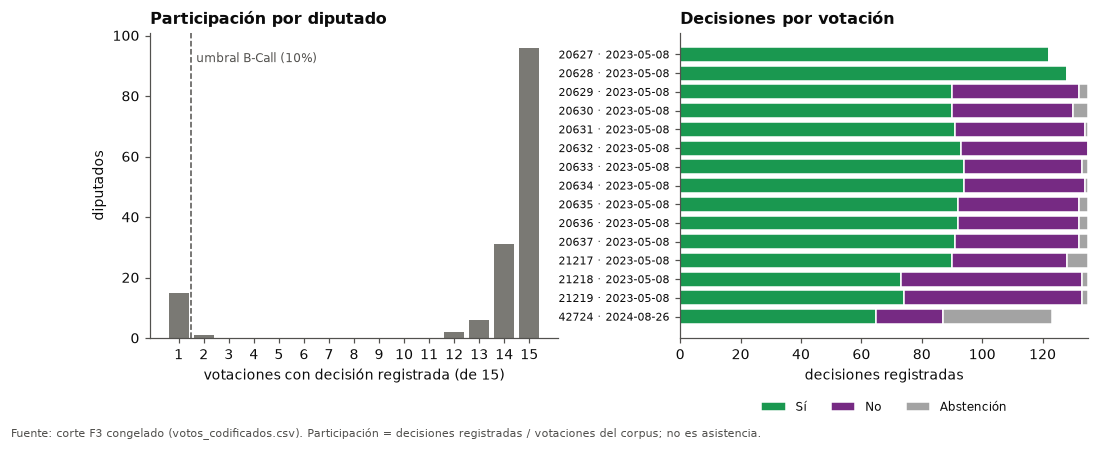

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={'wspace': 0.3})

dist = participacion['n_votos_observados'].value_counts().sort_index()
n_corpus = res['n_votaciones_corpus']
ax1.bar(dist.index, dist.values, width=0.8, color=vis.NEUTRO)
ax1.axvline(filtro['umbral'] * n_corpus, color=GRIS, ls='--', lw=1)
ax1.text(filtro['umbral'] * n_corpus + 0.2, dist.max() * 0.95,
         f"umbral B-Call ({filtro['umbral']:.0%})", color=GRIS, fontsize=8)
ax1.set_xticks(range(1, n_corpus + 1))
ax1.set_xlabel(f'votaciones con decisión registrada (de {n_corpus})')
ax1.set_ylabel('diputados')
ax1.set_title('Participación por diputado', loc='left', fontweight='bold')

por_votacion = (corpus.votos.groupby(['votacion_id', 'voto_nominal']).size()
                .unstack(fill_value=0).reindex(columns=list(COLORES), fill_value=0))
por_votacion = por_votacion.loc[corpus.votaciones['votacion_id']]
izq = np.zeros(len(por_votacion))
for cat, color in COLORES.items():
    ax2.barh(range(len(por_votacion)), por_votacion[cat], left=izq, color=color,
             edgecolor='white', linewidth=1, label=cat)
    izq += por_votacion[cat].to_numpy()
ax2.set_yticks(range(len(por_votacion)), [
    f'{v} · {f[:10]}' for v, f in zip(corpus.votaciones['votacion_id'],
                                      corpus.votaciones['fecha'])], fontsize=7)
ax2.invert_yaxis()
ax2.set_xlabel('decisiones registradas')
ax2.set_title('Decisiones por votación', loc='left', fontweight='bold')
ax2.legend(frameon=False, fontsize=8, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.17))
fig.text(0.01, -0.14, 'Fuente: corte F3 congelado (votos_codificados.csv). '
         'Participación = decisiones registradas / votaciones del corpus; no es asistencia.',
         fontsize=7.5, color=GRIS)
guardar(fig, 'participacion_y_decisiones.png')
plt.show()

La figura siguiente muestra cuántas decisiones registró cada partido en cada votación,
con el partido vigente en la fecha de la votación. Los partidos con uno o dos
integrantes aportan muy pocas decisiones por votación; por eso varias métricas
partidarias no se publican para ellos.

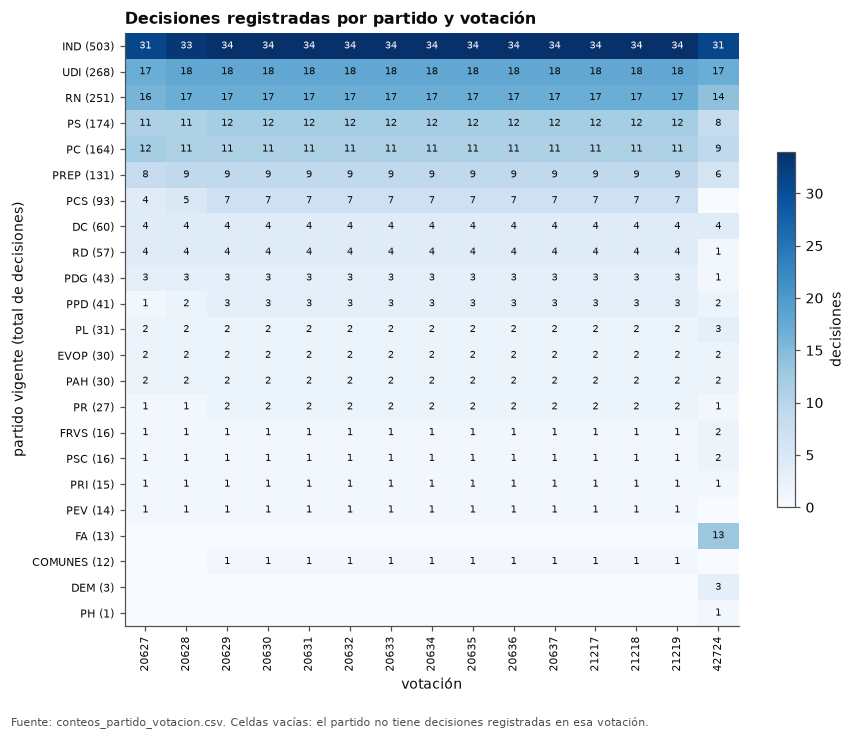

In [7]:
conteo_pv = (partido_votacion.pivot_table(index='partido_alias', columns='votacion_id',
                                          values='T', aggfunc='sum', fill_value=0)
             .reindex(columns=corpus.votaciones['votacion_id'], fill_value=0))
conteo_pv = conteo_pv.loc[conteo_pv.sum(axis=1).sort_values(ascending=False,
                                                           kind='stable').index]
fig, ax = plt.subplots(figsize=(9, 7))
imagen = ax.imshow(conteo_pv.to_numpy(), aspect='auto', cmap='Blues', vmin=0)
for (i, j), valor in np.ndenumerate(conteo_pv.to_numpy()):
    if valor:
        ax.text(j, i, int(valor), ha='center', va='center', fontsize=6.5,
                color='white' if valor > conteo_pv.to_numpy().max() * 0.55 else TEXTO)
ax.set_xticks(range(conteo_pv.shape[1]), conteo_pv.columns, rotation=90, fontsize=7)
ax.set_yticks(range(conteo_pv.shape[0]),
              [f'{p} ({int(t)})' for p, t in conteo_pv.sum(axis=1).items()], fontsize=7.5)
ax.set_xlabel('votación')
ax.set_ylabel('partido vigente (total de decisiones)')
ax.set_title('Decisiones registradas por partido y votación', loc='left',
             fontweight='bold')
fig.colorbar(imagen, ax=ax, shrink=0.6, label='decisiones')
fig.text(0.01, -0.02, 'Fuente: conteos_partido_votacion.csv. Celdas vacías: el partido '
         'no tiene decisiones registradas en esa votación.', fontsize=7.5, color=GRIS)
guardar(fig, 'decisiones_partido_votacion.png')
plt.show()

### 2.1 Conciliación de conteos con F3
Para cada votación se comparan los Sí, No y Abstención contados en el voto nominal
con los totales que informa F3. Una diferencia distinta de cero queda **pendiente**.

In [8]:
conc = reporte_participacion['conciliacion']
print(f"Votaciones que coinciden: {conc['votaciones_coinciden']} · "
      f"pendientes: {conc['votaciones_pendientes']}")
display(conciliacion_conteos)

Votaciones que coinciden: 15 · pendientes: 0


,votacion_id,obs_total_si,f3_total_si,dif_total_si,obs_total_no,f3_total_no,dif_total_no,obs_total_abstencion,f3_total_abstencion,dif_total_abstencion,f3_total_dispensado,estado
0,20627,122,122,0,0,0,0,0,0,0,0,coincide
1,20628,128,128,0,0,0,0,0,0,0,0,coincide
2,20629,90,90,0,42,42,0,3,3,0,0,coincide
3,20630,90,90,0,40,40,0,5,5,0,0,coincide
4,20631,91,91,0,43,43,0,1,1,0,0,coincide
5,20632,93,93,0,42,42,0,0,0,0,0,coincide
6,20633,94,94,0,39,39,0,2,2,0,0,coincide
7,20634,94,94,0,40,40,0,1,1,0,0,coincide
8,20635,92,92,0,40,40,0,3,3,0,0,coincide
9,20636,92,92,0,40,40,0,3,3,0,0,coincide


### 2.2 Consistencia con las salidas versionadas
Las tablas calculadas aquí deben ser idénticas a las exportadas en `F4/data/reports/`.

In [9]:
versionadas = {
    'participacion_observada.csv': participacion,
    'celdas_sin_registro.csv': sin_registro,
    'conteos_partido_votacion.csv': partido_votacion,
}
for nombre, tabla in versionadas.items():
    texto = tabla.to_csv(index=False, lineterminator='\n')
    guardado = (raiz / 'F4/data/reports' / nombre).read_text(encoding='utf-8')
    print(f'{nombre:32s} idéntica: {texto == guardado}')
    assert texto == guardado, nombre

participacion_observada.csv      idéntica: True
celdas_sin_registro.csv          idéntica: True
conteos_partido_votacion.csv     idéntica: True


## 3. Codificación del voto, máscara, matrices y variación
Esta sección no estima posiciones. Muestra cómo se transforma la tabla larga de F3 en
las vistas del voto y en las matrices diputado × votación que usan los métodos, y qué
votaciones tienen variación suficiente para distinguir posiciones.

### 3.1 Categorías del voto
Cada código de voto de la fuente se traduce a tres vistas según
`F4/config/diccionario_votos.toml`:

- **nominal**: Sí, No o Abstención;
- **ternaria**: +1, −1 y 0; la abstención es una decisión registrada y vale 0;
- **binaria**: 1 y 0 solo para Sí y No; la abstención queda vacía (NA).

Una combinación diputado × votación sin decisión registrada es **NA en todas las
vistas**. Nunca se codifica como 0: si se hiciera, el diputado quedaría artificialmente
cerca del centro y su partido parecería menos cohesionado.

In [10]:
from F4.src.analisis.codificacion import (  # noqa: E402
    CodificadorVotos,
    cargar_diccionario,
)

diccionario = cargar_diccionario(raiz / 'F4/config/diccionario_votos.toml')
display(pd.DataFrame([{
    'código fuente': r.codigo, 'etiqueta fuente': r.etiqueta_fuente,
    'nominal': r.nominal, 'ternaria': r.ternario,
    'binaria': 'NA' if r.binario is None else r.binario,
} for r in diccionario.reglas.values()]).style.hide(axis='index'))

tabla_f3 = pd.read_csv(raiz / manifiesto['entrada']['ruta'])
votos_codificados = CodificadorVotos(diccionario).transformar(tabla_f3)
display(votos_codificados.groupby(['voto_nominal', 'voto_ternario', 'voto_binario'],
                                  dropna=False).size().rename('decisiones').to_frame())

guardado = (raiz / 'F4/data/processed/votos_codificados.csv').read_text(encoding='utf-8')
coincide_votos = votos_codificados.to_csv(index=False, lineterminator='\n') == guardado
print('Coincide con votos_codificados.csv:', coincide_votos)
assert coincide_votos

código fuente,etiqueta fuente,nominal,ternaria,binaria
1,Afirmativo,Sí,1,1
0,En Contra,No,-1,0
2,Abstención,Abstención,0,NA


,,,decisiones
voto_nominal,voto_ternario,voto_binario,
Abstención,0,<NA>,68
No,-1,0,546
Sí,1,1,1379


Coincide con votos_codificados.csv: True


### 3.2 Máscara de observación y matrices
Con la tabla codificada se construyen, para los mismos diputados y votaciones:

- la **máscara de observación**: verdadero si hay una decisión registrada;
- las **matrices** binaria, ternaria y nominal, con NA donde no hay decisión.

Antes de construirlas se verifica que los conteos por categoría coincidan con la
auditoría de entrada. Después se comprueba que las celdas no vacías de cada matriz
correspondan exactamente a la máscara.

In [11]:
from F4.src.analisis.matrices import (  # noqa: E402
    ConstructorMatrices,
    validar_contra_auditoria,
)

votos_leidos = pd.read_csv(raiz / 'F4/data/processed/votos_codificados.csv')
validar_contra_auditoria(votos_leidos, raiz / 'F4/data/reports/auditoria_entrada.json')
matrices = ConstructorMatrices().construir(votos_leidos)

mascara = matrices.mascara.set_index('diputado_id')
ternaria = matrices.ternaria.set_index('diputado_id')
binaria = matrices.binaria.set_index('diputado_id')
display(pd.Series({
    'Diputados × votaciones': f'{matrices.n_diputados} × {matrices.n_votaciones}',
    'Celdas con decisión (máscara)': matrices.n_decisiones_observadas,
    'Celdas sin registro': matrices.n_celdas_sin_registro,
    'Ternaria: celdas no vacías': int(ternaria.notna().sum().sum()),
    'Binaria: celdas no vacías (sin abstenciones)': int(binaria.notna().sum().sum()),
    'Ternaria vacía exactamente donde la máscara es falsa':
        bool((ternaria.notna() == mascara).all().all()),
}, name='valor').to_frame())

for nombre, tabla in {
    'matriz_binaria.csv': matrices.binaria,
    'matriz_ternaria.csv': matrices.ternaria,
    'matriz_nominal.csv': matrices.nominal,
    'mascara_observacion.csv': matrices.mascara,
    'afiliacion_por_votacion.csv': matrices.afiliacion,
}.items():
    texto = tabla.to_csv(index=False, lineterminator='\n')
    guardado = (raiz / 'F4/data/processed' / nombre).read_text(encoding='utf-8')
    print(f'{nombre:30s} idéntica: {texto == guardado}')
    assert texto == guardado, nombre

,valor
Diputados × votaciones,151 × 15
Celdas con decisión (máscara),1993
Celdas sin registro,272
Ternaria: celdas no vacías,1993
Binaria: celdas no vacías (sin abstenciones),1925
Ternaria vacía exactamente donde la máscara es falsa,True


matriz_binaria.csv             idéntica: True
matriz_ternaria.csv            idéntica: True
matriz_nominal.csv             idéntica: True
mascara_observacion.csv        idéntica: True
afiliacion_por_votacion.csv    idéntica: True


La figura muestra la matriz ternaria completa. Cada fila es un diputado, ordenado por
participación, y cada columna una votación en orden cronológico. Las celdas grises no
tienen decisión registrada y no se imputan.

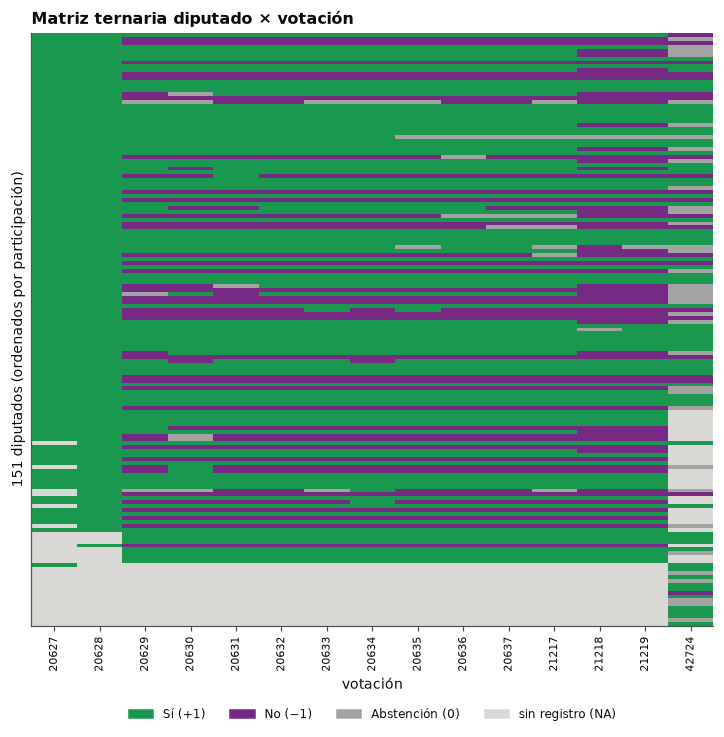

In [12]:
from matplotlib.colors import ListedColormap  # noqa: E402
from matplotlib.patches import Patch  # noqa: E402

orden_filas = mascara.sum(axis=1).sort_values(ascending=False, kind='stable').index
datos = ternaria.loc[orden_filas].astype('float')
fig, ax = plt.subplots(figsize=(8, 7))
ax.set_facecolor(vis.VOTO_SIN_REGISTRO)
ax.imshow(datos.replace({-1: 0, 0: 1, 1: 2}).to_numpy(), aspect='auto',
          interpolation='nearest',
          cmap=ListedColormap([COLORES['No'], COLORES['Abstención'], COLORES['Sí']]),
          vmin=0, vmax=2)
ax.set_xticks(range(datos.shape[1]), datos.columns, rotation=90, fontsize=7)
ax.set_yticks([])
ax.set_xlabel('votación')
ax.set_ylabel(f'{datos.shape[0]} diputados (ordenados por participación)')
ax.set_title('Matriz ternaria diputado × votación', loc='left', fontweight='bold')
ax.legend(handles=[Patch(color=COLORES['Sí'], label='Sí (+1)'),
                   Patch(color=COLORES['No'], label='No (−1)'),
                   Patch(color=COLORES['Abstención'], label='Abstención (0)'),
                   Patch(color=vis.VOTO_SIN_REGISTRO, label='sin registro (NA)')],
          frameon=False, fontsize=8, ncol=4, loc='upper center',
          bbox_to_anchor=(0.5, -0.12))
guardar(fig, 'matriz_ternaria.png')
plt.show()

### 3.3 Variación por votación
Una votación permite distinguir posiciones solo si los diputados votaron de forma
distinta. Para cada votación $j$ se informa el voto medio $M_j$ y la desviación
estándar poblacional $S_j$ de la vista ternaria, sobre las decisiones registradas:

$$M_j = \frac{1}{n_j}\sum_{i \in O_j} v_{ij}, \qquad
  S_j = \sqrt{\frac{1}{n_j}\sum_{i \in O_j} (v_{ij} - M_j)^2}$$

Si $S_j = 0$, todos votaron igual: la votación no aporta a la posición, pero sigue
contando para la cohesión y la afinidad. Son descriptivos de la matriz, no una
estimación.

In [13]:
variacion = pd.DataFrame({
    'fecha': votos_leidos.groupby('votacion_id')['fecha'].first(),
    'n_decisiones': ternaria.notna().sum(),
    'categorias_distintas': ternaria.nunique(),
    'M_j': ternaria.astype('float').mean(),
    'S_j': ternaria.astype('float').std(ddof=0),
})
variacion.index.name = 'votacion_id'
variacion['sin_variacion'] = variacion['S_j'].round(12).eq(0)
display(variacion.round(4))
print('Votaciones sin variación:',
      ', '.join(map(str, variacion.index[variacion['sin_variacion']])) or 'ninguna')

,fecha,n_decisiones,categorias_distintas,M_j,S_j,sin_variacion
votacion_id,,,,,,
20627,2023-05-08 19:05:22,122,1,1.0000,0.0000,True
20628,2023-05-08 19:06:49,128,1,1.0000,0.0000,True
20629,2023-05-08 19:08:21,135,3,0.3556,0.9227,False
20630,2023-05-08 19:09:23,135,3,0.3704,0.9087,False
20631,2023-05-08 19:10:13,135,3,0.3556,0.9307,False
20632,2023-05-08 19:11:06,135,2,0.3778,0.9259,False
20633,2023-05-08 19:11:56,135,3,0.4074,0.9051,False
20634,2023-05-08 19:12:58,135,3,0.4000,0.9125,False
20635,2023-05-08 19:13:51,135,3,0.3852,0.9107,False


Votaciones sin variación: 20627, 20628


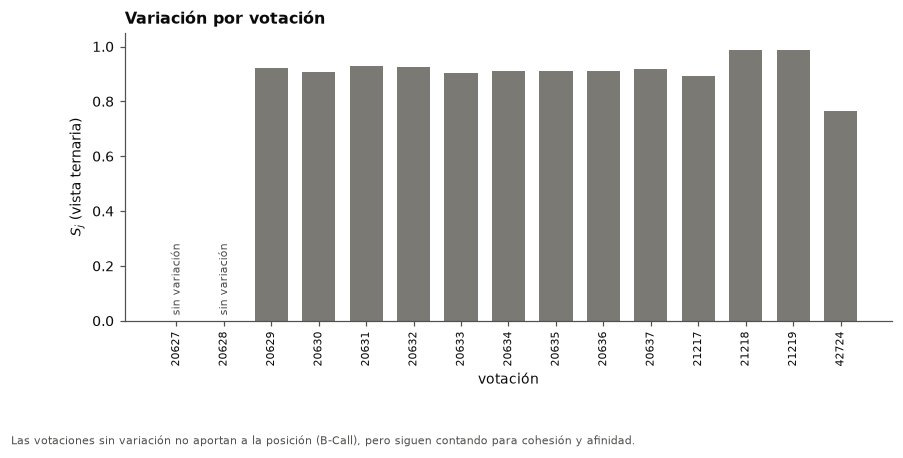

In [14]:
fig, ax = plt.subplots(figsize=(9, 3.4))
posiciones = range(len(variacion))
colores = [vis.SIN_DATO if sin else vis.NEUTRO for sin in variacion['sin_variacion']]
ax.bar(posiciones, variacion['S_j'], color=colores, width=0.7)
for x, (s_j, sin) in enumerate(zip(variacion['S_j'], variacion['sin_variacion'])):
    if sin:
        ax.text(x, 0.02, 'sin variación', ha='center', va='bottom', fontsize=7,
                rotation=90, color=GRIS)
ax.set_xticks(list(posiciones), variacion.index, rotation=90, fontsize=7)
ax.set_ylabel('$S_j$ (vista ternaria)')
ax.set_xlabel('votación')
ax.set_ylim(0, 1.05)
ax.set_title('Variación por votación', loc='left', fontweight='bold')
fig.text(0.01, -0.22, 'Las votaciones sin variación no aportan a la posición (B-Call), '
         'pero siguen contando para cohesión y afinidad.', fontsize=7.5, color=GRIS)
guardar(fig, 'variacion_por_votacion.png')
plt.show()

### 3.4 Universo por método
Cada método trabaja sobre un universo distinto (por ejemplo, B-Call excluye las
votaciones sin variación y a los diputados bajo el umbral de participación). El
archivo `universo_por_metodo.csv` debe registrar ese universo para cada método.

In [15]:
ruta_universo = raiz / 'F4/data/reports/universo_por_metodo.csv'
if ruta_universo.is_file() and ruta_universo.stat().st_size > 0:
    display(pd.read_csv(ruta_universo))
else:
    print('Pendiente: universo_por_metodo.csv está vacío. La descomposición del '
          'universo de B-Call se informa en la sección 4.2.')

,metodo,tarea,rol,vista,unidad,n_corpus,n_incluidos,n_excluidos,motivos_exclusion,n_diputados,n_partidos,n_votaciones_corpus,n_votaciones,votaciones_excluidas,motivo_votaciones_excluidas,orientacion_requerida,n_votaciones_orientables,unidad_cobertura,n_cobertura_040,n_cobertura_060,n_cobertura_080,regla_inclusion,excepciones,estado,fuente
0,bcall_automatico,C01,principal,ternaria,diputado,151,136,15,PARTICIPACION_NO_SUPERA_UMBRAL:15,136,21,15,13,20627|20628,SIN_VARIANZA_O_MENOS_DE_DOS_OBSERVACIONES:2,True,13.0,diputados del corpus con decisiones sobre vota...,135.0,135.0,135.0,participación > threshold sobre todas las vota...,d2 NA para 1 diputado(s) con menos de dos vota...,DESCRIPTIVO_PENDIENTE_G1_C02,F4/data/results/individual/bcall/bcall_diputad...
1,bcall_grupos_externos,C01,complementario,ternaria,diputado,151,108,43,SIN_CLUSTER:32|PARTICIPACION_NO_SUPERA_UMBRAL:11,108,21,15,13,20627|20628,SIN_VARIANZA_O_MENOS_DE_DOS_OBSERVACIONES:2,True,13.0,diputados del corpus con decisiones sobre vota...,135.0,135.0,135.0,grupo externo L/R único desde partidos observa...,SIN_CLUSTER corresponde a diputados sin clasif...,DESCRIPTIVO_COMPLEMENTARIO,F4/data/results/individual/bcall/seleccion_ext...
2,posicion_partido_votacion,C05,principal,ternaria_estandarizada_y_orientada,partido_x_votacion,259,194,65,DECISIONES_INSUFICIENTES_PARTIDO_VOTACION:65,134,17,15,13,20627|20628,SIN_VARIANZA_EN_BCALL,True,13.0,no aplica: sin padrón no hay denominador de in...,NaN,NaN,NaN,>= min_decisiones_por_partido_votacion (2) dec...,IND se agrega como grupo aunque no es partido;...,DESCRIPTIVO_SIN_PADRON,F4/data/results/partidos/posicion_partidaria.csv
3,posicion_partidaria_P_p,C05,principal,ternaria_estandarizada_y_orientada,partido,22,15,7,VOTACIONES_INSUFICIENTES_PARA_PERFIL_PARTIDARIO:7,132,14,15,13,20627|20628,SIN_VARIANZA_EN_BCALL,True,13.0,partidos con celdas incluidas sobre sus votaci...,17.0,17.0,17.0,>= min_votaciones_publicacion (2) votaciones c...,IND se agrega como grupo aunque no es partido;...,DESCRIPTIVO_SIN_PADRON,F4/data/results/partidos/posicion_partidaria.csv
4,cohesion_ai_entropia,C03,principal,nominal,partido_x_votacion,298,207,91,T_bajo_minimo:76|grupo_independientes:15,116,18,15,15,NaN,NaN,False,NaN,no aplica: sin padrón no hay denominador de in...,NaN,NaN,NaN,T >= min_decisiones_publicacion_partido_votaci...,Las votaciones unánimes se conservan y se marc...,DESCRIPTIVO_SIN_PADRON,F4/data/results/partidos/cohesion_por_votacion...
5,cohesion_rice,C03,principal,nominal,partido_x_votacion,298,204,94,T_bajo_minimo:76|grupo_independientes:15|binar...,114,17,15,15,NaN,NaN,False,NaN,no aplica: sin padrón no hay denominador de in...,NaN,NaN,NaN,Y + N >= min_votos_binarios_publicacion_rice (...,Las votaciones unánimes se conservan y se marc...,DESCRIPTIVO_SIN_PADRON,F4/data/results/partidos/cohesion_por_votacion...
6,cohesion_resumen_partido,C03,principal,nominal,partido,23,14,9,votaciones_validas_bajo_minimo:8|grupo_indepen...,103,14,15,15,NaN,NaN,False,NaN,grupos con votaciones válidas de AI sobre vota...,16.0,16.0,16.0,>= min_votaciones_resumen_principal (2) votaci...,IND se calcula como grupo de independientes y ...,DESCRIPTIVO_SIN_PADRON,F4/data/results/partidos/resumen_cohesion.csv
7,afinidad_pares,C06,auxiliar,nominal,par_de_diputados,11325,9141,2184,COVOTOS_INSUFICIENTES:1761|SIN_COVOTOS:423,136,21,15,15,NaN,NaN,False,NaN,pares con co-votos sobre votaciones del corpus,9045.0,9045.0,9045.0,>= pares.min_covotos (2) co-votos,Acuerdo y Hamming se informan también sin vota...,DESCRIPTIVO_SIN_PADRON,F4/data/results/pares/afinidad_diputados.csv
8,clustering,C07,contraste_descriptivo,nominal,diputado,151,135,16,COBERTURA_INSUFICIENTE:16,135,21,15,13,20627|20628,SIN_VARIACION_OBSERVADA:2,False,NaN,diputados del corpus con decisiones sobre vota...,135.0,135.0,135.0,cobertura >= 0.80 sobre votaciones informativa...,"Sensible al bloque articulos_206xx (ARI = 0,461).",DESCRIPTIVO_SOBRE_VOTOS_REGISTRADOS,F4/data/results/grupos/clusters_diputados.c

## 4. Conciliación de resultados entre métodos
Cada método produce sus propias tablas a partir del mismo corte. Esta sección compara
sus conteos y universos con la fuente y entre sí, sin recalcular ningún método. Cada
control termina como:

- **coincide**: el mismo número en ambas tablas;
- **explicada**: hay diferencia, pero su causa, el universo afectado y la decisión
  están documentados;
- **pendiente**: la diferencia no tiene causa conocida o falta la salida.

Ninguna diferencia se corrige aquí: solo se informa.

In [16]:
from F4.src.analisis.conciliacion import desde_repositorio as conciliacion_desde_repositorio

conciliador, traza_conciliacion = conciliacion_desde_repositorio(raiz)
reporte_conciliacion = conciliador.conciliar(traza_conciliacion)

controles = pd.DataFrame(reporte_conciliacion['controles'])
print('Controles por estado:', reporte_conciliacion['resumen'])
display(controles[['control', 'referencia', 'comparado', 'n_referencia', 'n_comparado',
                   'diferencia', 'estado']].style.hide(axis='index').map(
    lambda v: {'pendiente': f"color:{vis.ESTADOS_TEXTO['error']};font-weight:bold",
               'explicada': f"color:{vis.ESTADOS_TEXTO['advertencia']};font-weight:bold"}.get(v, ''),
    subset=['estado']))

Controles por estado: {'coincide': 20, 'explicada': 3, 'pendiente': 0}


control,referencia,comparado,n_referencia,n_comparado,diferencia,estado
decisiones_fuente_vs_auditoria,auditoria_entrada,votos_codificados,1993.000000,1993,0.000000,coincide
decisiones_vs_mascara,votos_codificados,mascara_observacion,1993.000000,1993,0.000000,coincide
decisiones_vs_participacion,votos_codificados,participacion_observada,1993.000000,1993,0.000000,coincide
celdas_sin_registro,mascara_observacion,participacion_observada,272.000000,272,0.000000,coincide
decisiones_vs_cohesion,votos_codificados,cohesion_por_votacion,1993.000000,1993,0.000000,coincide
vista_binaria,votos_codificados,matriz_binaria,1993.000000,1925,-68.000000,explicada
abstenciones_en_ternaria,votos_codificados,matriz_ternaria (valor 0),68.000000,68,0.000000,coincide
celdas_partido_votacion_cohesion,afiliacion_por_votacion,cohesion,0.000000,0,0.000000,coincide
celdas_partido_votacion_conteos_participacion,afiliacion_por_votacion,conteos_participacion,0.000000,0,0.000000,coincide
universo_posicion,votos_codificados,posicion_partidaria (partido × votación),1993.000000,1728,-265.000000,explicada


### 4.1 Diferencias explicadas y pendientes
Para cada control que no coincide se muestra su causa, el universo al que afecta y la
decisión tomada.

In [17]:
excepciones = pd.DataFrame(reporte_conciliacion['excepciones'])
display(excepciones[['control', 'estado', 'diferencia', 'causa', 'universo', 'decision']]
        .style.hide(axis='index'))

control,estado,diferencia,causa,universo,decision
vista_binaria,explicada,-68.000000,La vista binaria excluye las 68 abstenciones.,decisiones Sí/No,Correcto por diseño: Rice usa solo Sí/No; AI y entropía usan las tres categorías.
universo_posicion,explicada,-265.000000,"B-Call excluye 250 decisiones de las votaciones unánimes 20627, 20628 (sin varianza) y 15 decisiones de 15 diputados que no superan el filtro de participación.",votaciones con varianza × diputados sobre el filtro,Diferencia esperada por diseño de B-Call; la cohesión conserva estas decisiones.
celdas_bajo_minimo_posicion,explicada,nan,65 celdas partido × votación con menos de 2 decisiones no entran al perfil del partido.,celdas partido × votación,Regla [posicion_partidos].min_decisiones_por_partido_votacion de analisis.toml.


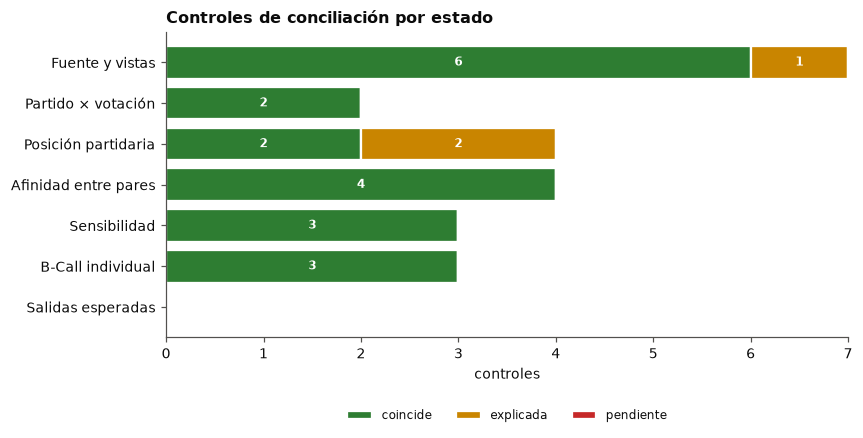

In [18]:
grupos_controles = {
    'Fuente y vistas': conciliador.controles_fuente(),
    'Partido × votación': conciliador.controles_partido_votacion(),
    'Posición partidaria': conciliador.controles_posicion(),
    'Afinidad entre pares': conciliador.controles_afinidad(),
    'Sensibilidad': conciliador.controles_sensibilidad(),
    'B-Call individual': conciliador.controles_bcall_individual(),
    'Salidas esperadas': conciliador.salidas_faltantes(),
}
ESTADOS = {'coincide': vis.ESTADOS['ok'], 'explicada': vis.ESTADOS['advertencia'],
           'pendiente': vis.ESTADOS['error']}
por_grupo = pd.DataFrame({g: pd.Series([c.estado for c in cs]).value_counts()
                          for g, cs in grupos_controles.items()}).T
por_grupo = por_grupo.reindex(columns=list(ESTADOS), fill_value=0).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 3.6))
izq = np.zeros(len(por_grupo))
for estado, color in ESTADOS.items():
    valores = por_grupo[estado].to_numpy()
    ax.barh(range(len(por_grupo)), valores, left=izq, color=color, edgecolor='white',
            linewidth=1.5, label=estado)
    for y, (x0, v) in enumerate(zip(izq, valores)):
        if v:
            ax.text(x0 + v / 2, y, str(v), ha='center', va='center', color='white',
                    fontsize=8, fontweight='bold')
    izq += valores
ax.set_yticks(range(len(por_grupo)), por_grupo.index)
ax.invert_yaxis()
ax.set_xlabel('controles')
ax.set_title('Controles de conciliación por estado', loc='left', fontweight='bold')
ax.legend(frameon=False, fontsize=8, ncol=3, loc='upper center',
          bbox_to_anchor=(0.5, -0.2))
guardar(fig, 'controles_conciliacion.png')
plt.show()

### 4.2 Universo de B-Call y casos especiales
El universo de B-Call es menor que el total de decisiones porque excluye las votaciones
unánimes (no permiten distinguir posiciones) y a los diputados bajo el umbral de
participación. Se informan también los diputados que cambiaron de partido durante el
período: cada métrica usa el partido vigente en la fecha de cada votación.

In [19]:
display(pd.Series(reporte_conciliacion['descomposicion_universo_bcall'],
                  name='decisiones').to_frame())

,decisiones
n_total,1993
votaciones_unanimes,"[20627, 20628]"
n_en_unanimes,250
diputados_bajo_filtro,15
n_de_diputados_bajo_filtro,15
n_universo_esperado,1728


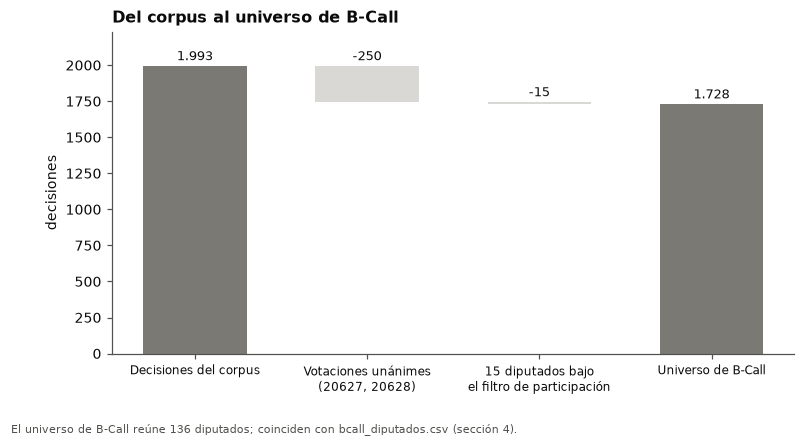

Votaciones unánimes: 20627, 20628


,tratamiento
cohesion,se conservan y se marcan (votacion_unanime_sala)
posicion_partidaria,excluidas por B-Call (sin varianza)
afinidad,se informan columnas con y sin unánimes


Diputados con más de un partido en el período: 20


,diputado_id,partidos
0,1003,"[IND, UDI]"
1,1025,"[IND, RN]"
2,1034,"[IND, PEV]"
3,1037,"[FA, PCS]"
4,1054,"[IND, PSC]"
5,1057,"[DEM, IND]"
6,1062,"[DEM, IND]"
7,1068,"[COMUNES, FA]"
8,1074,"[IND, PC]"
9,1087,"[FA, PCS]"


In [20]:
d = reporte_conciliacion['descomposicion_universo_bcall']
n_diputados_bcall = next(c['n_comparado'] for c in reporte_conciliacion['controles']
                         if c['control'] == 'diputados_bcall')
pasos = [('Decisiones del corpus', d['n_total'], 0, vis.NEUTRO),
         (f"Votaciones unánimes\n({', '.join(map(str, d['votaciones_unanimes']))})",
          -d['n_en_unanimes'], d['n_total'] - d['n_en_unanimes'], vis.SIN_DATO),
         (f"{d['diputados_bajo_filtro']} diputados bajo\nel filtro de participación",
          -d['n_de_diputados_bajo_filtro'], d['n_universo_esperado'], vis.SIN_DATO),
         ('Universo de B-Call', d['n_universo_esperado'], 0, vis.NEUTRO)]
fig, ax = plt.subplots(figsize=(8, 3.8))
for x, (etiqueta, valor, base, color) in enumerate(pasos):
    ax.bar(x, abs(valor), bottom=base, color=color, width=0.6)
    texto = f'{valor:+,}' if 0 < x < 3 else f'{valor:,}'
    ax.text(x, base + abs(valor) + 20, texto.replace(',', '.'), ha='center', va='bottom',
            fontsize=8.5)
ax.set_xticks(range(len(pasos)), [p[0] for p in pasos], fontsize=8)
ax.set_ylabel('decisiones')
ax.set_ylim(0, d['n_total'] * 1.12)
ax.set_title('Del corpus al universo de B-Call', loc='left', fontweight='bold')
fig.text(0.01, -0.08, f'El universo de B-Call reúne {n_diputados_bcall} diputados; '
         'coinciden con bcall_diputados.csv (sección 4).', fontsize=7.5, color=GRIS)
guardar(fig, 'universo_bcall.png')
plt.show()
unanimes = reporte_conciliacion['votaciones_unanimes']
print('Votaciones unánimes:', ', '.join(map(str, unanimes['ids'])))
display(pd.Series(unanimes['tratamiento'], name='tratamiento').to_frame())
cambiantes = reporte_conciliacion['partidos_cambiantes']
print(f"Diputados con más de un partido en el período: {cambiantes['n_diputados']}")
display(pd.DataFrame(cambiantes['detalle']))

### 4.3 Posición partidaria frente a la posición de sus integrantes
La posición de un partido ($P_p$) se compara con la mediana de la posición individual
($d_1$) de sus integrantes. Una diferencia mayor que la tolerancia se considera
explicada si el partido es heterogéneo (rango intercuartílico de $d_1$ amplio) o si
vota dividido (Agreement Index menor que 1).

In [21]:
pvd = reporte_conciliacion['posicion_vs_d1']
print('Tolerancia:', pvd['tolerancia'])
display(pd.DataFrame(pvd['detalle']))

Tolerancia: 0.1


,partido_id,P_p,mediana_d1,iqr_d1,diferencia,mediana_ai,clase
0,COMUNES,NaN,-0.726106,0.000000,NaN,NaN,sin_P_p
1,DC,-0.726106,-0.726106,0.000000,0.000000,1.000000,consistente
2,DEM,NaN,-0.726106,0.000000,NaN,1.000000,sin_P_p
3,EVOP,-0.073550,-0.073550,0.173331,0.000000,1.000000,consistente
4,FA,NaN,-0.726106,0.000000,NaN,1.000000,sin_P_p
5,FRVS,NaN,-0.726106,0.000000,NaN,1.000000,sin_P_p
6,IND,-0.131459,-0.638218,1.959769,0.506759,NaN,divergente_explicada_por_heterogeneidad
7,PAH,-0.726106,-0.726106,0.000000,0.000000,1.000000,consistente
8,PC,-0.726106,-0.726106,0.000000,0.000000,1.000000,consistente
9,PCS,-0.714709,-0.726106,0.005699,0.011398,1.000000,consistente


### 4.4 Consistencia con el reporte versionado
Se compara el resultado con `conciliacion_resultados.json`. Los controles deben
coincidir; las huellas (SHA-256) de las entradas cambian cuando otro método regenera
su salida, y se listan para saber qué archivos se actualizaron después del reporte.

In [22]:
versionado = json.loads((raiz / 'F4/data/reports/conciliacion_resultados.json')
                        .read_text(encoding='utf-8'))
actual = json.loads(json.dumps(reporte_conciliacion, ensure_ascii=False, default=str))
print('Resumen igual al versionado:', actual['resumen'] == versionado['resumen'])
print('Controles iguales al versionado:', actual['controles'] == versionado['controles'])
assert actual['resumen'] == versionado['resumen']
assert actual['controles'] == versionado['controles']
cambiaron = [ruta for ruta, sha in actual['trazabilidad'].items()
             if versionado['trazabilidad'].get(ruta) != sha]
print('Entradas actualizadas después del reporte:', cambiaron or 'ninguna')

Resumen igual al versionado: True
Controles iguales al versionado: True
Entradas actualizadas después del reporte: ninguna


## 5. Reproducibilidad
Se registran el commit del repositorio, las versiones de las librerías y las huellas
de las entradas usadas en esta ejecución.

In [23]:
import platform
import subprocess

import matplotlib


def _git(*args):
    try:
        return subprocess.run(['git', *args], cwd=raiz, capture_output=True, text=True,
                              check=True).stdout.strip()
    except (OSError, subprocess.CalledProcessError):
        return None

# --no-optional-locks: consultar el estado sin bloquear el índice del repositorio.
estado_git = _git('--no-optional-locks', 'status', '--porcelain') or ''
display(pd.Series({
    'Commit del repositorio': _git('rev-parse', 'HEAD'),
    # El propio notebook cambia al ejecutarse, por eso no cuenta como modificación.
    'Otros archivos modificados': (
        [linea for linea in estado_git.splitlines()
         if not linea.endswith('F4_01_datos_y_cobertura.ipynb')] or 'ninguno'),
    'Python': platform.python_version(),
    'pandas': pd.__version__,
    'matplotlib': matplotlib.__version__,
    'Commit del corte F3': manifiesto['reproducibilidad']['commit_git'],
    'SHA-256 de la entrada': manifiesto['entrada']['sha256'],
    'SHA-256 de votos_codificados': trazabilidad['votos_codificados_sha256'],
}, name='valor').to_frame())
display(pd.Series(figuras_generadas, name='figuras generadas').to_frame())
# Llegar aquí implica que todas las comprobaciones anteriores se cumplieron.
print('F4_01_APROBADO=True')


,valor
Commit del repositorio,0fd1a04d4386d025528e515cd0d0d1bfc45727b1
Otros archivos modificados,[M F4/data/reports/conciliacion_resultados.jso...
Python,3.12.13
pandas,3.0.5
matplotlib,3.11.1
Commit del corte F3,022d4d0ac3d453430e1473ac603ef5ee0ca29d9f
SHA-256 de la entrada,5bf21cbcb360da9074db00ac78de4ab53f2de3c061fa99...
SHA-256 de votos_codificados,b38ad20de073b9ed9beb5b5c355204b431f5d2fd1a5f97...


,figuras generadas
0,participacion_y_decisiones.png
1,decisiones_partido_votacion.png
2,matriz_ternaria.png
3,variacion_por_votacion.png
4,controles_conciliacion.png
5,universo_bcall.png


F4_01_APROBADO=True


## 6. Síntesis
- La entrada corresponde al corte congelado y pasa la auditoría sin errores; las
  advertencias tienen explicación documentada.
- Los conteos de Sí, No y Abstención coinciden con los totales de F3 en todas las
  votaciones.
- La codificación, la máscara y las matrices reproducen las tablas versionadas; las
  celdas sin decisión son NA en todas las vistas y nunca 0.
- La participación describe lo registrado, no la asistencia: no hay padrón verificable.
  Las celdas sin registro se informan, nunca se cuentan como cero.
- Los resultados de los métodos son consistentes entre sí; las diferencias tienen causa
  documentada o quedan como pendientes explícitos.

In [24]:
display(pd.DataFrame({
    'valor': [
        resumen_auditoria['estado_entrada'],
        f"{resumen_auditoria['resumen']['ok']} ok · "
        f"{resumen_auditoria['resumen']['advertencia']} advertencias · "
        f"{resumen_auditoria['resumen']['error']} errores",
        res['n_decisiones_observadas'],
        res['n_celdas_sin_registro'],
        filtro['n_no_superan'],
        f"{conc['votaciones_coinciden']} de {res['n_votaciones_corpus']}",
        f"{matrices.n_diputados} × {matrices.n_votaciones}",
        int(variacion['sin_variacion'].sum()),
        f"{reporte_conciliacion['resumen']['coincide']} coinciden · "
        f"{reporte_conciliacion['resumen']['explicada']} explicadas · "
        f"{reporte_conciliacion['resumen']['pendiente']} pendientes",
    ]}, index=[
        'Estado de la entrada', 'Reglas de auditoría', 'Decisiones registradas',
        'Celdas sin registro', f"Diputados con participación ≤ {filtro['umbral']:.0%}",
        'Votaciones que concilian con F3', 'Matriz diputado × votación',
        'Votaciones sin variación', 'Controles entre métodos',
    ]))

,valor
Estado de la entrada,aprobada
Reglas de auditoría,14 ok · 8 advertencias · 0 errores
Decisiones registradas,1993
Celdas sin registro,272
Diputados con participación ≤ 10%,15
Votaciones que concilian con F3,15 de 15
Matriz diputado × votación,151 × 15
Votaciones sin variación,2
Controles entre métodos,20 coinciden · 3 explicadas · 0 pendientes
